In [1]:
import pandas as pd
from ase.db import connect

db = connect("c2db.db")

data = []
for row in db.select():

    entry = {
        "id": row.id,
        "formula": row.formula,
        "natoms": row.natoms,
        "energy": row.energy,
        **row.key_value_pairs,  # Unpacks calculated properties (gaps, magnetic moments, etc.)
    }
    data.append(entry)

df = pd.DataFrame(data)

# Clean/Inspect DataFrame
print(df.info())
print(df[["formula", "gap", "gap_gw", "efermi"]].head())

<class 'pandas.DataFrame'>
RangeIndex: 16905 entries, 0 to 16904
Data columns (total 87 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      16905 non-null  int64  
 1   formula                 16905 non-null  str    
 2   natoms                  16905 non-null  int64  
 3   energy                  16905 non-null  float64
 4   folder                  16905 non-null  str    
 5   uid                     16905 non-null  str    
 6   olduid                  16789 non-null  str    
 7   international           16905 non-null  str    
 8   number                  16905 non-null  int64  
 9   has_inversion_symmetry  16905 non-null  bool   
 10  lgnum                   16905 non-null  int64  
 11  layergroup              16905 non-null  str    
 12  bravais_type            16695 non-null  str    
 13  bravais_search          16695 non-null  str    
 14  thickness               16905 non-null  float64
 

# Task - 0 Exploring Data

In [2]:
df.columns

Index(['id', 'formula', 'natoms', 'energy', 'folder', 'uid', 'olduid',
       'international', 'number', 'has_inversion_symmetry', 'lgnum',
       'layergroup', 'bravais_type', 'bravais_search', 'thickness', 'label',
       'gap_dir_nosoc', 'evac', 'efermi', 'gap', 'gap_dir', 'vbm', 'cbm',
       'evacdiff', 'dipz', 'minhessianeig', 'dyn_stab', 'gap_hse',
       'gap_dir_hse', 'vbm_hse', 'cbm_hse', 'efermi_hse', 'alphax_el',
       'alphay_el', 'alphaz_el', 'alphax_lat', 'alphax', 'alphay_lat',
       'alphay', 'alphaz_lat', 'alphaz', 'emass_cbm', 'emass_vbm',
       'is_magnetic', 'spin_axis', 'dE_zx', 'dE_zy', 'ehull', 'hform',
       'cod_id', 'is_magnetic_u', 'magmom_u', 'spin_axis_u', 'dE_zx_u',
       'dE_zy_u', 'efermi_u', 'gap_u', 'gap_dir_u', 'vbm_u', 'cbm_u',
       'is_ferroelectric', 'P_spontaneous_norm', 'icsd_id', 'J_u', 'lam_u',
       'A_u', 'spin_u', 'N_nn_u', 'J', 'lam', 'A', 'spin', 'N_nn', 'topology',
       'plasmafrequency_x', 'plasmafrequency_y', 'halfmetal_gap',

In [3]:
cols = df.columns

print(df[cols].head())

   id       formula  natoms      energy  \
0   1     InNaAs2S6      10  -41.329140   
1   2     CuScAs2S6      10  -46.645235   
2   3  Ag2Cr2As4O12      20 -123.723922   
3   4  Ag2Cr2As4O12      20 -124.709924   
4   5    AlLiSb2Te6      10  -35.061072   

                                              folder            uid  \
0  /home/niflheim2/cmr/C2DB-ASR/tree_LDP/ABC2D6/I...   1InNaAs2S6-1   
1  /home/niflheim2/cmr/C2DB-ASR/tree_LDP/ABC2D6/C...   1CuScAs2S6-1   
2  /home/niflheim2/cmr/C2DB-ASR/tree_LDP/ABC2D6/A...   2AgCrAs2O6-2   
3  /home/niflheim2/cmr/C2DB-ASR/tree_LDP/ABC2D6/A...   2AgCrAs2O6-1   
4  /home/niflheim2/cmr/C2DB-ASR/tree_LDP/ABC2D6/A...  1AlLiSb2Te6-1   

                      olduid international  number  has_inversion_symmetry  \
0     InNaAs2S6-b86d8d87fbda            C2       5                   False   
1     CuScAs2S6-04403e673f20          P312     149                   False   
2  Ag2Cr2As4O12-317a92ccf0bd          P2/c      13                    True   
3 

In [4]:
df.columns

Index(['id', 'formula', 'natoms', 'energy', 'folder', 'uid', 'olduid',
       'international', 'number', 'has_inversion_symmetry', 'lgnum',
       'layergroup', 'bravais_type', 'bravais_search', 'thickness', 'label',
       'gap_dir_nosoc', 'evac', 'efermi', 'gap', 'gap_dir', 'vbm', 'cbm',
       'evacdiff', 'dipz', 'minhessianeig', 'dyn_stab', 'gap_hse',
       'gap_dir_hse', 'vbm_hse', 'cbm_hse', 'efermi_hse', 'alphax_el',
       'alphay_el', 'alphaz_el', 'alphax_lat', 'alphax', 'alphay_lat',
       'alphay', 'alphaz_lat', 'alphaz', 'emass_cbm', 'emass_vbm',
       'is_magnetic', 'spin_axis', 'dE_zx', 'dE_zy', 'ehull', 'hform',
       'cod_id', 'is_magnetic_u', 'magmom_u', 'spin_axis_u', 'dE_zx_u',
       'dE_zy_u', 'efermi_u', 'gap_u', 'gap_dir_u', 'vbm_u', 'cbm_u',
       'is_ferroelectric', 'P_spontaneous_norm', 'icsd_id', 'J_u', 'lam_u',
       'A_u', 'spin_u', 'N_nn_u', 'J', 'lam', 'A', 'spin', 'N_nn', 'topology',
       'plasmafrequency_x', 'plasmafrequency_y', 'halfmetal_gap',

In [5]:
analysis_keys = [
    # Structure & Composition
    "formula", "natoms", "thickness", "has_inversion_symmetry", 
    "international", "number", "layergroup", "lgnum", "bravais_type", "bravais_search", "label",
    
    # Energetics & Stability
    "energy", "hform", "ehull", "dyn_stab", "minhessianeig",
    
    # PBE Electronic Properties
    "gap", "gap_dir", "gap_dir_nosoc", "vbm", "cbm", "efermi", "evac", "evacdiff",
    "emass_cbm", "emass_vbm", "halfmetal_gap", "halfmetal_gap_dir", "topology",
    
    # Advanced Band Gaps (HSE & GW)
    "gap_hse", "gap_dir_hse", "vbm_hse", "cbm_hse", "efermi_hse", 
    "halfmetal_gap_hse", "halfmetal_gap_dir_hse",
    "gap_gw", "gap_dir_gw", "vbm_gw", "cbm_gw", "efermi_gw", "E_B",
    
    # Dielectric & Optical
    "dipz", "alphax", "alphay", "alphaz", 
    "alphax_el", "alphay_el", "alphaz_el", 
    "alphax_lat", "alphay_lat", "alphaz_lat", 
    "plasmafrequency_x", "plasmafrequency_y",
    
    # Magnetism (PBE & DFT+U)
    "is_magnetic", "spin_axis", "dE_zx", "dE_zy", "spin", "J", "lam", "A", "N_nn",
    "is_magnetic_u", "magmom_u", "spin_axis_u", "dE_zx_u", "dE_zy_u", 
    "efermi_u", "gap_u", "gap_dir_u", "vbm_u", "cbm_u", 
    "J_u", "lam_u", "A_u", "spin_u", "N_nn_u",
    
    # Ferroelectricity
    "is_ferroelectric", "P_spontaneous_norm"
]

In [6]:
data = df[analysis_keys].copy()

In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 16905 entries, 0 to 16904
Data columns (total 80 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   formula                 16905 non-null  str    
 1   natoms                  16905 non-null  int64  
 2   thickness               16905 non-null  float64
 3   has_inversion_symmetry  16905 non-null  bool   
 4   international           16905 non-null  str    
 5   number                  16905 non-null  int64  
 6   layergroup              16905 non-null  str    
 7   lgnum                   16905 non-null  int64  
 8   bravais_type            16695 non-null  str    
 9   bravais_search          16695 non-null  str    
 10  label                   16766 non-null  str    
 11  energy                  16905 non-null  float64
 12  hform                   16905 non-null  float64
 13  ehull                   16905 non-null  float64
 14  dyn_stab                16905 non-null  str    
 

In [8]:
print("Number of columns in the DataFrame:", len(df.columns))
print("Number of columns for analysis:", len(data.columns))

Number of columns in the DataFrame: 87
Number of columns for analysis: 80


In [9]:
# 1. Dataset where 'E_B' has NO null values
df_eb_notnull =data[data['E_B'].notna()].copy()

# 2. Dataset where 'gap_gw' has NO null values
df_gap_notnull = data[data['gap_gw'].notna()].copy()

# 3. Dataset where BOTH 'E_B' AND 'gap_gw' have NO null values
df_both_notnull = data[data['E_B'].notna() & data['gap_gw'].notna()].copy()

### Up to now :
1. There were 16905 data points. --> data (data set)
2. But 283 entries which have non zero 'E_b' , and 'gap_gw'
3.  Now df_eb_notnull (data set)


# Task - 01 : Division X, y 

In [10]:
df_eb_notnull.info()


<class 'pandas.DataFrame'>
Index: 370 entries, 2764 to 13376
Data columns (total 80 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   formula                 370 non-null    str    
 1   natoms                  370 non-null    int64  
 2   thickness               370 non-null    float64
 3   has_inversion_symmetry  370 non-null    bool   
 4   international           370 non-null    str    
 5   number                  370 non-null    int64  
 6   layergroup              370 non-null    str    
 7   lgnum                   370 non-null    int64  
 8   bravais_type            370 non-null    str    
 9   bravais_search          370 non-null    str    
 10  label                   370 non-null    str    
 11  energy                  370 non-null    float64
 12  hform                   370 non-null    float64
 13  ehull                   370 non-null    float64
 14  dyn_stab                370 non-null    str    
 15  

In [11]:
df_both_notnull.info()

<class 'pandas.DataFrame'>
Index: 283 entries, 2764 to 13376
Data columns (total 80 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   formula                 283 non-null    str    
 1   natoms                  283 non-null    int64  
 2   thickness               283 non-null    float64
 3   has_inversion_symmetry  283 non-null    bool   
 4   international           283 non-null    str    
 5   number                  283 non-null    int64  
 6   layergroup              283 non-null    str    
 7   lgnum                   283 non-null    int64  
 8   bravais_type            283 non-null    str    
 9   bravais_search          283 non-null    str    
 10  label                   283 non-null    str    
 11  energy                  283 non-null    float64
 12  hform                   283 non-null    float64
 13  ehull                   283 non-null    float64
 14  dyn_stab                283 non-null    str    
 15  

In [34]:
df_both_notnull["is_ferroelectric"].notnull().sum()

np.int64(7)

In [35]:
X, y = df_both_notnull.drop(columns=["E_B", "gap_gw"]), df_both_notnull[["E_B", "gap_gw"]]

In [36]:
X.shape, y.shape

((283, 78), (283, 2))

# Tasks - 03: Pase 01, Working on Data Set



In [15]:
corr_01 = y["E_B"].corr(y["gap_gw"])

corr_01

np.float64(0.7307748405589916)

In [16]:
X.info()

<class 'pandas.DataFrame'>
Index: 283 entries, 2764 to 13376
Data columns (total 78 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   formula                 283 non-null    str    
 1   natoms                  283 non-null    int64  
 2   thickness               283 non-null    float64
 3   has_inversion_symmetry  283 non-null    bool   
 4   international           283 non-null    str    
 5   number                  283 non-null    int64  
 6   layergroup              283 non-null    str    
 7   lgnum                   283 non-null    int64  
 8   bravais_type            283 non-null    str    
 9   bravais_search          283 non-null    str    
 10  label                   283 non-null    str    
 11  energy                  283 non-null    float64
 12  hform                   283 non-null    float64
 13  ehull                   283 non-null    float64
 14  dyn_stab                283 non-null    str    
 15  

In [17]:
y.info()

<class 'pandas.DataFrame'>
Index: 283 entries, 2764 to 13376
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   E_B     283 non-null    float64
 1   gap_gw  283 non-null    float64
dtypes: float64(2)
memory usage: 6.6 KB


In [18]:
y[["E_B", "gap_gw"]].head()

,E_B,gap_gw
2764,1.860429,9.598559
2765,1.793056,8.209944
2775,1.352613,2.403058
2782,0.063864,5.398439
2800,0.419845,1.376623


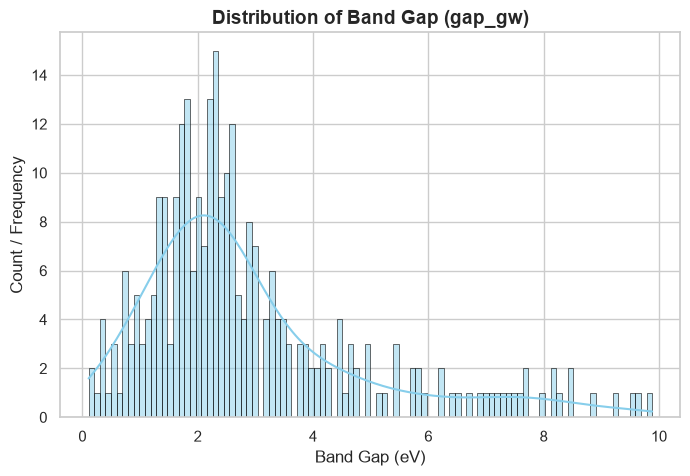

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean plot style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 5))

# Plot histogram with smooth density curve (KDE)
# Seaborn automatically drops NaN values
sns.histplot(df_both_notnull['gap_gw'].dropna(), kde=True, bins=100, color='skyblue', edgecolor='black')

plt.title("Distribution of Band Gap (gap_gw)", fontsize=14, fontweight='bold')
plt.xlabel("Band Gap (eV)", fontsize=12)
plt.ylabel("Count / Frequency", fontsize=12)

plt.show()

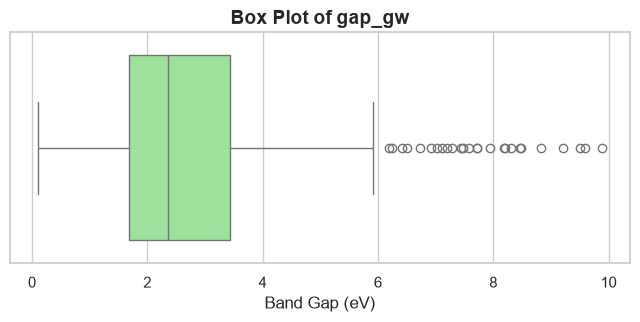

In [20]:
plt.figure(figsize=(8, 3))

sns.boxplot(x=df_both_notnull['gap_gw'], color='lightgreen')

plt.title("Box Plot of gap_gw", fontsize=14, fontweight='bold')
plt.xlabel("Band Gap (eV)", fontsize=12)

plt.show()

In [21]:
df_both_notnull["gap_gw"].describe()

count    283.000000
mean       2.901978
std        1.961865
min        0.108102
25%        1.687050
50%        2.353488
75%        3.429068
max        9.883013
Name: gap_gw, dtype: float64

<Figure size 800x300 with 0 Axes>

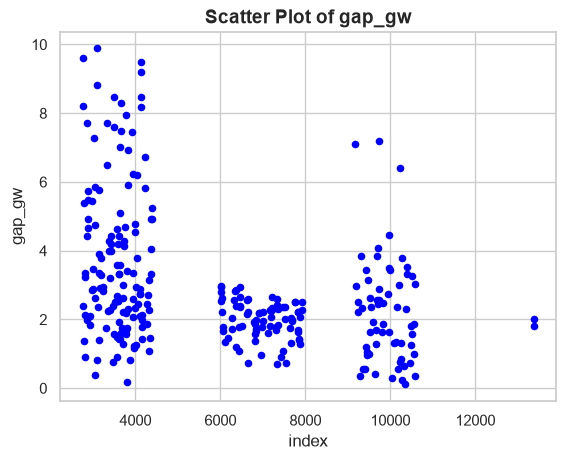

In [37]:
plt.figure(figsize=(8, 3))

y.reset_index().plot.scatter(x='index', y="gap_gw", color='blue')

plt.title("Scatter Plot of gap_gw", fontsize=14, fontweight='bold')

plt.show()

In [23]:
lower= 1.0
upper = 3.5
range_count_gw = df_both_notnull["gap_gw"].between(lower, upper).sum()

percentage = (range_count_gw / len(df_both_notnull)) * 100

print(f"Number of entries with gap_gw between {lower} and {upper} eV: {range_count_gw}")
print(f"Percentage of entries with gap_gw between {lower} and {upper} eV: {percentage:.2f}%")


Number of entries with gap_gw between 1.0 and 3.5 eV: 189
Percentage of entries with gap_gw between 1.0 and 3.5 eV: 66.78%


In [24]:
df_both_notnull["gap_gw"].between(lower, upper).sum()

np.int64(189)

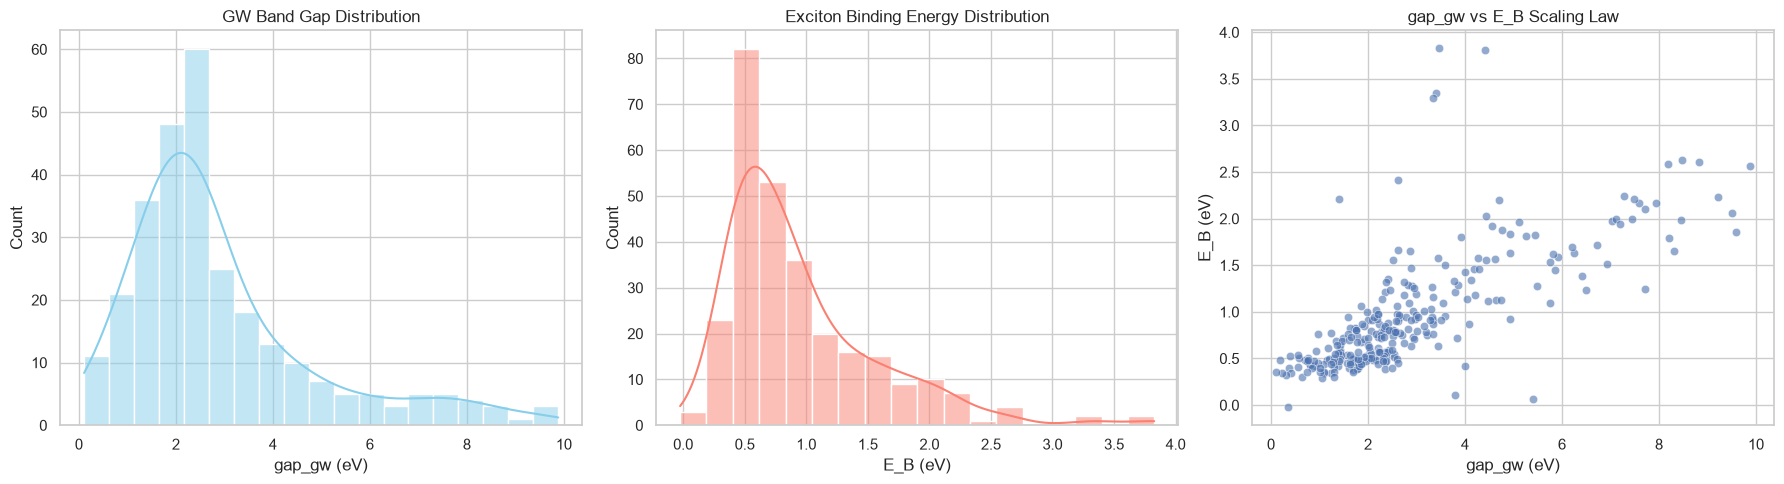

In [ ]:
# 2. Plotting Target Distributions & Correlation
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Target 1: GW Gap
sns.histplot(y['gap_gw'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('GW Band Gap Distribution')
axes[0].set_xlabel('gap_gw (eV)')

# Target 2: Exciton Binding Energy
sns.histplot(y['E_B'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Exciton Binding Energy Distribution')
axes[1].set_xlabel('E_B (eV)')

# Target vs Target Relationship
sns.scatterplot(data=y, x='gap_gw', y='E_B', alpha=0.6, ax=axes[2])
axes[2].set_title('gap_gw vs E_B Scaling Law')
axes[2].set_xlabel('gap_gw (eV)')
axes[2].set_ylabel('E_B (eV)')

plt.tight_layout()
plt.show()

In [26]:
X.info()

<class 'pandas.DataFrame'>
Index: 283 entries, 2764 to 13376
Data columns (total 78 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   formula                 283 non-null    str    
 1   natoms                  283 non-null    int64  
 2   thickness               283 non-null    float64
 3   has_inversion_symmetry  283 non-null    bool   
 4   international           283 non-null    str    
 5   number                  283 non-null    int64  
 6   layergroup              283 non-null    str    
 7   lgnum                   283 non-null    int64  
 8   bravais_type            283 non-null    str    
 9   bravais_search          283 non-null    str    
 10  label                   283 non-null    str    
 11  energy                  283 non-null    float64
 12  hform                   283 non-null    float64
 13  ehull                   283 non-null    float64
 14  dyn_stab                283 non-null    str    
 15  

In [44]:
# 1. Drop columns that are completely empty (0 non-null values)
X_clean = X.dropna(axis=1, how='all')

# 2. Drop columns where missing values exceed a specific threshold (e.g., >30% missing)
missing_threshold = 0.30
null_fraction = X_clean.isnull().mean()
cols_to_drop = null_fraction[null_fraction > missing_threshold].index

print(f"Dropping {len(cols_to_drop)} sparse columns with >{missing_threshold*100:.0f}% missing values:")
print(list(cols_to_drop))

X_clean = X_clean.drop(columns=cols_to_drop)

Dropping 23 sparse columns with >30% missing values:
['topology', 'spin', 'J', 'lam', 'A', 'N_nn', 'is_magnetic_u', 'magmom_u', 'spin_axis_u', 'dE_zx_u', 'dE_zy_u', 'efermi_u', 'gap_u', 'gap_dir_u', 'vbm_u', 'cbm_u', 'J_u', 'lam_u', 'A_u', 'spin_u', 'N_nn_u', 'is_ferroelectric', 'P_spontaneous_norm']


In [45]:
X_clean.isnull().sum()

formula                    0
natoms                     0
thickness                  0
has_inversion_symmetry     0
international              0
number                     0
layergroup                 0
lgnum                      0
bravais_type               0
bravais_search             0
label                      0
energy                     0
hform                      0
ehull                      0
dyn_stab                   0
minhessianeig              0
gap                        0
gap_dir                    0
gap_dir_nosoc              0
vbm                        0
cbm                        0
efermi                     0
evac                       0
evacdiff                   0
emass_cbm                  0
emass_vbm                  0
gap_hse                    0
gap_dir_hse                0
vbm_hse                    0
cbm_hse                    0
efermi_hse                 0
gap_dir_gw                 0
vbm_gw                     0
cbm_gw                     0
efermi_gw     

In [46]:
from sklearn.impute import SimpleImputer
import numpy as np

num_cols_with_nulls = X_clean.select_dtypes(
    include=[np.number]
).columns[X_clean.select_dtypes(include=[np.number]).isnull().any()]

imputer = SimpleImputer(strategy='median')
X_clean[num_cols_with_nulls] = imputer.fit_transform(X_clean[num_cols_with_nulls])

print(f"\nCleaned feature matrix shape: {X_clean.shape}")


Cleaned feature matrix shape: (283, 51)


In [29]:
# 1. Identifiers / Metadata (High cardinality text — keep for reference, exclude from ML inputs)
id_cols = ['formula', 'label']

# 2. Boolean features
bool_cols = X_clean.select_dtypes(include=['bool']).columns.tolist()

# 3. Categorical / String features
cat_cols = X_clean.select_dtypes(include=['object', 'str']).columns.tolist()
# Remove metadata columns from categorical list if present
cat_cols = [c for c in cat_cols if c not in id_cols]

# 4. Numerical features (int64, float64)
num_cols = X_clean.select_dtypes(include=[np.number]).columns.tolist()

print(f"Identifiers ({len(id_cols)}):", id_cols)
print(f"Boolean ({len(bool_cols)}):", bool_cols)
print(f"Categorical ({len(cat_cols)}):", cat_cols)
print(f"Numerical ({len(num_cols)}):", num_cols[:10], "... total:", len(num_cols))

Identifiers (2): ['formula', 'label']
Boolean (1): ['has_inversion_symmetry']
Categorical (7): ['international', 'layergroup', 'bravais_type', 'bravais_search', 'dyn_stab', 'is_magnetic', 'spin_axis']
Numerical (41): ['natoms', 'thickness', 'number', 'lgnum', 'energy', 'hform', 'ehull', 'minhessianeig', 'gap', 'gap_dir'] ... total: 41


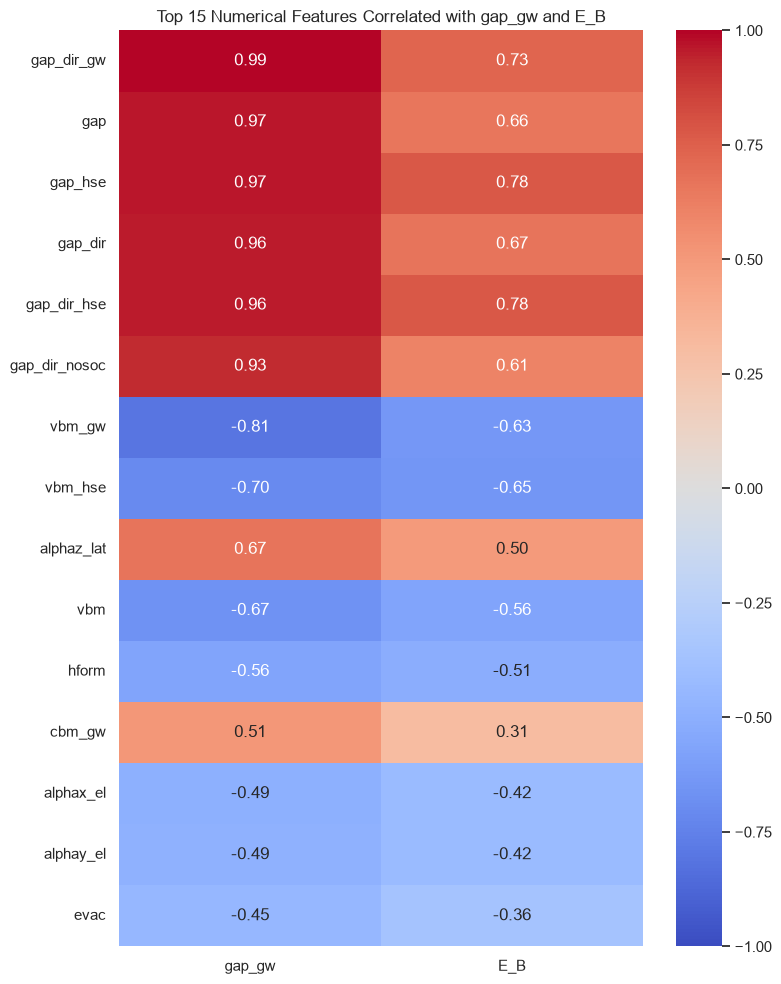


Found 33 highly correlated feature pairs (|r| > 0.85):
  - lgnum <--> number: r = 0.99
  - gap_dir <--> gap: r = 0.98
  - gap_dir_nosoc <--> gap: r = 0.94
  - gap_dir_nosoc <--> gap_dir: r = 0.95
  - efermi <--> vbm: r = 0.87
  - gap_hse <--> gap: r = 0.95
  - gap_hse <--> gap_dir: r = 0.93
  - gap_hse <--> gap_dir_nosoc: r = 0.88
  - gap_dir_hse <--> gap: r = 0.93
  - gap_dir_hse <--> gap_dir: r = 0.94


In [30]:
# --- Step A: Combine Cleaned Numerical Features with Targets ---
# Assuming y is a DataFrame with columns ['gap_gw', 'E_B']
df_analysis = pd.concat([X_clean[num_cols], y], axis=1)

# Compute Pearson correlation matrix
corr_matrix = df_analysis.corr(method='pearson')

# --- Step B: Correlation of Numerical Features with Targets ---
target_corr = corr_matrix[['gap_gw', 'E_B']].drop(index=['gap_gw', 'E_B'])

# Sort by absolute correlation with GW gap
target_corr_sorted = target_corr.reindex(
    target_corr['gap_gw'].abs().sort_values(ascending=False).index
)

# Plot top 15 correlated features with targets
plt.figure(figsize=(8, 10))
sns.heatmap(target_corr_sorted.head(15), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Top 15 Numerical Features Correlated with gap_gw and E_B')
plt.tight_layout()
plt.show()


# --- Step C: Finding Multicollinear Features (Redundant Inputs) ---
# Find pairs of input features with |correlation| > 0.85
threshold = 0.85
feature_corr = X_clean[num_cols].corr().abs()

# Select upper triangle of correlation matrix
upper = feature_corr.where(np.triu(np.ones(feature_corr.shape), k=1).astype(bool))

# Find features with correlation greater than threshold
high_corr_pairs = [
    (column, row, upper.loc[row, column]) 
    for column in upper.columns 
    for row in upper.index 
    if upper.loc[row, column] > threshold
]

print(f"\nFound {len(high_corr_pairs)} highly correlated feature pairs (|r| > {threshold}):")
for f1, f2, val in high_corr_pairs[:10]: # Print top 10 pairs
    print(f"  - {f1} <--> {f2}: r = {val:.2f}")

In [31]:
corr_matrix

,natoms,thickness,number,lgnum,energy,hform,ehull,minhessianeig,gap,gap_dir,...,alphaz_el,alphax_lat,alphay_lat,alphaz_lat,plasmafrequency_x,plasmafrequency_y,dE_zx,dE_zy,E_B,gap_gw
natoms,1.000000,0.611656,-0.327059,-0.319951,-0.434682,0.042363,-0.050022,0.034094,-0.135679,-0.161921,...,0.291577,0.133628,0.216856,0.010135,0.111468,0.111468,-0.006425,-0.006503,-0.142172,-0.160443
thickness,0.611656,1.000000,0.218905,0.213130,-0.080652,-0.007440,-0.147463,0.083183,-0.156949,-0.162077,...,0.584228,0.054842,0.032286,0.030616,0.097036,0.097036,-0.008496,-0.008674,-0.227341,-0.204249
number,-0.327059,0.218905,1.000000,0.993226,0.008442,-0.283969,0.134659,-0.139409,0.116947,0.132726,...,0.083974,-0.024883,-0.190104,0.110591,0.043459,0.043459,-0.006148,-0.006155,0.158675,0.150292
lgnum,-0.319951,0.213130,0.993226,1.000000,0.012264,-0.280164,0.122188,-0.131199,0.127282,0.140157,...,0.080549,-0.017473,-0.167308,0.118455,0.040618,0.040618,-0.004136,-0.004128,0.161992,0.160568
energy,-0.434682,-0.080652,0.008442,0.012264,1.000000,0.365952,-0.176007,0.146792,0.187621,0.179916,...,-0.060335,-0.041273,-0.030264,0.137569,-0.172382,-0.172382,0.009744,0.010045,0.065738,0.174195
hform,0.042363,-0.007440,-0.283969,-0.280164,0.365952,1.000000,0.070080,0.217682,-0.516109,-0.555275,...,0.261489,-0.049168,0.020369,-0.509608,0.048353,0.048353,0.001639,0.001970,-0.509409,-0.562585
ehull,-0.050022,-0.147463,0.134659,0.122188,-0.176007,0.070080,1.000000,-0.400998,-0.150605,-0.174352,...,-0.116368,-0.003010,-0.053909,-0.025030,0.134244,0.134244,-0.102413,-0.101672,0.052198,-0.105095
minhessianeig,0.034094,0.083183,-0.139409,-0.131199,0.146792,0.217682,-0.400998,1.000000,-0.023870,-0.021866,...,0.138168,0.020274,0.043032,0.052503,-0.003204,-0.003204,0.004659,0.004716,-0.194108,-0.097710
gap,-0.135679,-0.156949,0.116947,0.127282,0.187621,-0.516109,-0.150605,-0.023870,1.000000,0.981557,...,-0.366943,-0.075240,-0.101503,0.662294,-0.065738,-0.065738,-0.029514,-0.029743,0.664027,0.968240
gap_dir,-0.161921,-0.162077,0.132726,0.140157,0.179916,-0.555275,-0.174352,-0.021866,0.981557,1.000000,...,-0.371046,-0.087912,-0.119900,0.661396,-0.075476,-0.075476,-0.021942,-0.022214,0.666185,0.958804
